In [1]:
# Import packages
from typing import Optional
import phenograph
import scanpy as sc
from anndata import AnnData
from anndata import concat
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import os
import pandas as pd
import numpy as np
from scipy.stats import entropy
import subprocess
import palantir
import sys
import random
from collections import OrderedDict
import re
from itertools import chain
import warnings
sys.path.append('/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages')
import harmony
from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors
from phenograph.core import find_neighbors, neighbor_graph, jaccard_kernel
%matplotlib inline

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


In [2]:
# This is the full patient 146 dataset
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/KG146_Patient_Organoid.h5ad')
adata_patient

AnnData object with n_obs × n_vars = 12016 × 20157
    obs: 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'original_total_counts', 'log10_original_total_counts', 'original_mito_counts', 'log10_original_mito_counts', 'Sample ID', 'emptyDrops_Total', 'emptyDrops_LogProb', 'emptyDrops_PValue', 'emptyDrops_FDR', 'latent_cell_probability', 'PhenoGraph_clusters', 'Smilie Cell Type', 'log10_n_counts', 'frac_counts_gt1_reads', 'n_reads', 'n_reads_per_count', 'n_counts_vs_ED_LogProb', 'n_counts_vs_n_genes_by_counts', 'n_flagged_metrics', 'DC 1', 'DC 2', 'DC 3', 'DC 4', 'DC 5', 'DC 6', 'DC 7', 'Palantir Diff. Potential', 'Palantir Pseudotime', 'Combined Fetal Signature', 'First Tri

In [3]:
# Prepare the patient 146 dataset
adata_patient = adata_patient[~((adata_patient.obs['Cell State'] == 'NA') | (adata_patient.obs['Cell State'] == 'nan') | (adata_patient.obs['Cell State'] == 'Organoid'))]
adata_patient.obs['Cell State'].value_counts()
adata_patient

View of AnnData object with n_obs × n_vars = 1304 × 20157
    obs: 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'original_total_counts', 'log10_original_total_counts', 'original_mito_counts', 'log10_original_mito_counts', 'Sample ID', 'emptyDrops_Total', 'emptyDrops_LogProb', 'emptyDrops_PValue', 'emptyDrops_FDR', 'latent_cell_probability', 'PhenoGraph_clusters', 'Smilie Cell Type', 'log10_n_counts', 'frac_counts_gt1_reads', 'n_reads', 'n_reads_per_count', 'n_counts_vs_ED_LogProb', 'n_counts_vs_n_genes_by_counts', 'n_flagged_metrics', 'DC 1', 'DC 2', 'DC 3', 'DC 4', 'DC 5', 'DC 6', 'DC 7', 'Palantir Diff. Potential', 'Palantir Pseudotime', 'Combined Fetal Signature', 'Fi

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

...

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

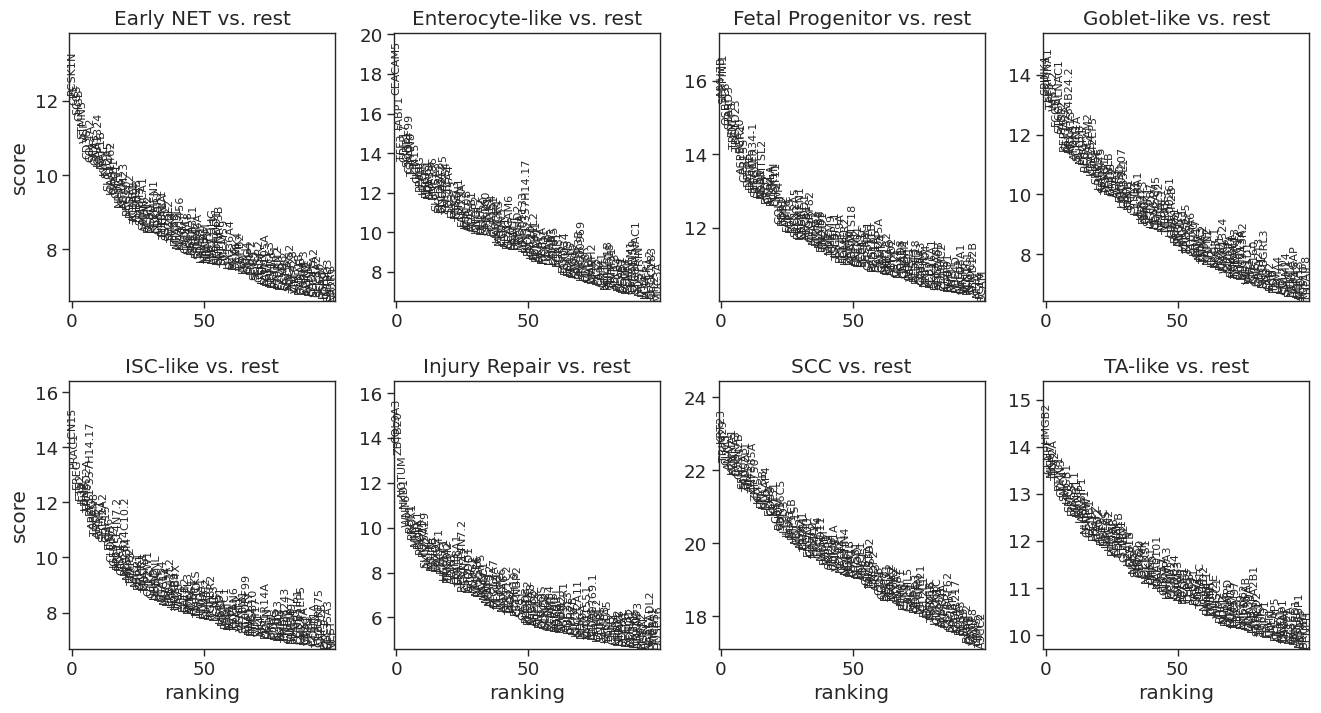

In [4]:
# Identify DEGs in this group
sc.tl.rank_genes_groups(adata_patient, groupby='Cell State', method='wilcoxon', key_added = "wilcoxon", n_genes=100)
sc.pl.rank_genes_groups(adata_patient, n_genes=100, sharey=False, key="wilcoxon")

results_dict = adata_patient.uns['wilcoxon']

# Create a dictionary to store dataframes for each group
deg_dfs = {}

# Iterate over each group and create a dataframe
for group in results_dict['names'].dtype.names:
    df = pd.DataFrame(results_dict['names'][group], columns=['gene'])
    df['logfoldchanges'] = results_dict['logfoldchanges'][group]
    df['pvals'] = results_dict['pvals'][group]
    df['pvals_adj'] = results_dict['pvals_adj'][group]
    
    # Filter out highly significant genes
    significant_genes = df[(df['logfoldchanges'].abs() > np.log2(1.5)) & (df['pvals_adj'] < 0.05)]
    
    # Store the filtered dataframe in the dictionary
    deg_dfs[group] = significant_genes
    
# Concatenate significant genes from different groups into a single dataframe
concatenated_data = pd.concat([deg_dfs[group] for group in deg_dfs], axis=0)

In [5]:
# Use the significant genes for PCA
significant_genes_pca = concatenated_data['gene'].tolist()

# Subset the original AnnData object to include only significant genes
adata_patient = adata_patient[:, significant_genes_pca]

In [6]:
adata_patient

View of AnnData object with n_obs × n_vars = 1304 × 798
    obs: 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'original_total_counts', 'log10_original_total_counts', 'original_mito_counts', 'log10_original_mito_counts', 'Sample ID', 'emptyDrops_Total', 'emptyDrops_LogProb', 'emptyDrops_PValue', 'emptyDrops_FDR', 'latent_cell_probability', 'PhenoGraph_clusters', 'Smilie Cell Type', 'log10_n_counts', 'frac_counts_gt1_reads', 'n_reads', 'n_reads_per_count', 'n_counts_vs_ED_LogProb', 'n_counts_vs_n_genes_by_counts', 'n_flagged_metrics', 'DC 1', 'DC 2', 'DC 3', 'DC 4', 'DC 5', 'DC 6', 'DC 7', 'Palantir Diff. Potential', 'Palantir Pseudotime', 'Combined Fetal Signature', 'Firs

In [7]:
# This is the organoid data
adata_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.h5ad')
adata_organoid

AnnData object with n_obs × n_vars = 52800 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_

In [8]:
# Create a 'Cell State' column where we fill in the values as NA
adata_organoid.obs['Cell State'] = pd.NA
adata_organoid.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph,leiden,Cell State
KG146Li_BASE_shCtrl_TGCGGGTTCTCACCCA-1,0.122256,0.999999,9510.026367,0.782633,1127,7.028201,2686,7.896181,49.404319,54.988831,...,146,Metastatic,BASE,CTRL,1,2,146_M_BASE_CTRL_1,12,11,NaN
KG146Li_HISC_shCtrl_ACTATCTGTAACGGTG-1,0.071823,0.999999,7005.529297,0.771213,1320,7.186144,2528,7.835579,42.761076,47.112342,...,146,Metastatic,HISC,CTRL,1,3,146_M_HISC_CTRL_1,19,6,NaN
146P_HISC_shZFP36L2_3_TTGTGTTTCCCAAGTA-1,0.031075,0.999950,14507.531250,1.027227,3045,8.021585,9831,9.193398,30.708982,44.634320,...,146,Primary,HISC,ZFP_KD,1,6,146_P_HISC_ZFPKD_1,10,13,NaN
146Li_dedifferentiation_shCtrl_ATCGATGCACGGAAGT-1,0.033828,0.999974,12912.831055,1.133512,3009,8.009695,8806,9.083302,35.010220,47.172382,...,146,Metastatic,Dedifferentiated,CTRL,1,4,146_M_Dediff_CTRL_1,25,29,NaN
146P_HISC_shCTRL_GTCGCGACAAGGCTTT-1,0.053984,0.999998,13370.254883,0.725564,2447,7.803027,6547,8.786915,27.157477,39.376814,...,146,Primary,HISC,CTRL,1,6,146_P_HISC_CTRL_1,11,21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1,0.097506,0.999994,13538.197266,0.864753,2075,7.638198,4775,8.471359,45.026178,49.759162,...,146,Primary,Dedifferentiated,CTRL,1,8,146_P_Dediff_CTRL_1,3,12,NaN
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1,0.010058,0.999955,17959.175781,1.036444,4895,8.496174,16396,9.704854,24.646255,33.355697,...,146,Metastatic,BASE,ZFP_KD,2,2,146_M_BASE_ZFPKD_2,14,16,NaN
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1,0.016410,0.999943,8206.400391,1.086645,3007,8.009031,7291,8.894533,26.800165,36.716500,...,146,Metastatic,HISC,ZFP_KD,2,3,146_M_HISC_ZFPKD_2,16,18,NaN
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1,0.017183,0.999955,16893.447266,1.458533,4552,8.423542,11879,9.382612,28.436737,32.452227,...,146,Metastatic,Dedifferentiated,CTRL,1,4,146_M_Dediff_CTRL_1,23,36,NaN


In [9]:
# Ensure both datas have the same set of genes
common_genes = adata_patient.var_names.intersection(adata_organoid.var_names)

# Subset both objects to include only common genes
adata_patient_common = adata_patient[:, common_genes].copy()
adata_organoid_common = adata_organoid[:, common_genes].copy()

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [19]:
# Subset the organoid dataset into different conditions

# Base media, liver metastasis
adata_base_liver = adata_organoid_common[(adata_organoid_common.obs['Culture_Media'] == 'BASE') & 
                                  (adata_organoid_common.obs['Tumor_Site'] == 'Metastatic')]
# Base media, primary 
adata_base_primary = adata_organoid_common[(adata_organoid_common.obs['Culture_Media'] == 'BASE') & 
                                  (adata_organoid_common.obs['Tumor_Site'] == 'Primary')]

# HISC media, liver metastasis
adata_hisc_liver = adata_organoid_common[(adata_organoid_common.obs['Culture_Media'] == 'HISC') & 
                                  (adata_organoid_common.obs['Tumor_Site'] == 'Metastatic')]
# HISC media, primary
adata_hisc_primary = adata_organoid_common[(adata_organoid_common.obs['Culture_Media'] == 'HISC') & 
                                  (adata_organoid_common.obs['Tumor_Site'] == 'Primary')]

# Dedifferentiated media, liver metastasis
adata_dedif_liver = adata_organoid_common[(adata_organoid_common.obs['Culture_Media'] == 'Dedifferentiated') & 
                                  (adata_organoid_common.obs['Tumor_Site'] == 'Metastatic')]
# Dedifferentiated media, primary
adata_dedif_primary = adata_organoid_common[(adata_organoid_common.obs['Culture_Media'] == 'Dedifferentiated') & 
                                  (adata_organoid_common.obs['Tumor_Site'] == 'Primary')]

In [150]:
# FOR PRIMARY DEDIFFERENTIATED
# Concatenate the data using anndata.concat
dedif_primary_patient_organoid = concat([adata_patient_common, adata_dedif_primary])

# Extract count matrix
dedif_primary_counts = pd.DataFrame(dedif_primary_patient_organoid.X.toarray(),
                                       index=dedif_primary_patient_organoid.obs_names,
                                       columns=dedif_primary_patient_organoid.var_names)

# Reprocess the data
# 1. Normalization
norm_df = harmony.utils.normalize_counts(dedif_primary_counts)

# Gene selection
hvg_genes = harmony.utils.hvg_genes(norm_df)

# Log transform
data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/merge.py:1263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/harmony/utils.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersion']


In [124]:
# FOR LIVER DEDIFFERENTIATED
# Concatenate the data using anndata.concat
dedif_liver_patient_organoid = concat([adata_patient_common, adata_dedif_liver])

# Extract count matrix
dedif_liver_counts = pd.DataFrame(dedif_liver_patient_organoid.X.toarray(),
                                       index=dedif_liver_patient_organoid.obs_names,
                                       columns=dedif_liver_patient_organoid.var_names)

# Reprocess the data
# 1. Normalization
norm_df = harmony.utils.normalize_counts(dedif_liver_counts)

# Gene selection
hvg_genes = harmony.utils.hvg_genes(norm_df)

# Log transform
data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/merge.py:1263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/harmony/utils.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersion']


In [101]:
# FOR PRIMARY HISC
# Concatenate the data using anndata.concat
hisc_primary_patient_organoid = concat([adata_patient_common, adata_hisc_primary])

# Extract count matrix
hisc_primary_counts = pd.DataFrame(hisc_primary_patient_organoid.X.toarray(),
                                       index=hisc_primary_patient_organoid.obs_names,
                                       columns=hisc_primary_patient_organoid.var_names)

# Reprocess the data
# 1. Normalization
norm_df = harmony.utils.normalize_counts(hisc_primary_counts)

# Gene selection
hvg_genes = harmony.utils.hvg_genes(norm_df)

# Log transform
data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/merge.py:1263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/harmony/utils.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersion']


In [78]:
# FOR METASTATIC HISC
# Concatenate the data using anndata.concat
hisc_liver_patient_organoid = concat([adata_patient_common, adata_hisc_liver])

# Extract count matrix
hisc_liver_counts = pd.DataFrame(hisc_liver_patient_organoid.X.toarray(),
                                       index=hisc_liver_patient_organoid.obs_names,
                                       columns=hisc_liver_patient_organoid.var_names)

# Reprocess the data
# 1. Normalization
norm_df = harmony.utils.normalize_counts(hisc_liver_counts)

# Gene selection
hvg_genes = harmony.utils.hvg_genes(norm_df)

# Log transform
data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/merge.py:1263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/harmony/utils.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersion']


In [22]:
# FOR METASTATIC BASE
# Concatenate the data using anndata.concat
base_liver_patient_organoid = concat([adata_patient_common, adata_base_liver])

# Extract count matrix
base_liver_counts = pd.DataFrame(base_liver_patient_organoid.X.toarray(),
                                       index=base_liver_patient_organoid.obs_names,
                                       columns=base_liver_patient_organoid.var_names)

# Reprocess the data
# 1. Normalization
norm_df = harmony.utils.normalize_counts(base_liver_counts)

# Gene selection
hvg_genes = harmony.utils.hvg_genes(norm_df)

# Log transform
data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/merge.py:1263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/harmony/utils.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersion']


In [55]:
# FOR PRIMARY BASE
# Concatenate the data using anndata.concat
base_primary_patient_organoid = concat([adata_patient_common, adata_base_primary])

# Extract count matrix
base_primary_counts = pd.DataFrame(base_primary_patient_organoid.X.toarray(),
                                       index=base_primary_patient_organoid.obs_names,
                                       columns=base_primary_patient_organoid.var_names)

# Reprocess the data
# 1. Normalization
norm_df = harmony.utils.normalize_counts(base_primary_counts)

# Gene selection
hvg_genes = harmony.utils.hvg_genes(norm_df)

# Log transform
data_df = harmony.utils.log_transform(norm_df.loc[:,hvg_genes])

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/merge.py:1263: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(
/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/harmony/utils.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersion']


## Get Affinities

In [151]:
# The patient data is defined as those cells with 'KG146M' in the row name
# Define the time point connections
tp = pd.Series(index=data_df.index)

# Define pattern for Patient cells
patient_pattern = '_KG146'

# Use str.contains to check if the patient pattern is present in the cell identifier
patient_cells = data_df.index[data_df.index.str.contains(patient_pattern)]

# Assign 'Patient' to the corresponding cells in the series
tp[patient_cells] = 'Patient'

# The remaining cells (not classified as Patient) are Organoid cells
tp.fillna('Organoid', inplace=True)

organoid_count = (tp == 'Organoid').sum()
patient_count = (tp == 'Patient').sum()

print(f"Number of Organoid cells: {organoid_count}")
print(f"Number of Patient cells: {patient_count}")

Number of Organoid cells: 9467
Number of Patient cells: 1304


/scratch/lsftmp/3835733.tmpdir/ipykernel_70381/4160515974.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Patient' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tp[patient_cells] = 'Patient'


In [152]:
# Define timepoint connections
timepoint_connections = pd.DataFrame(columns=[0, 1])
index = 0
timepoint_connections.loc[index, :] = ['Organoid', 'Patient']; index += 1
timepoint_connections

,0,1
0,Organoid,Patient


In [153]:
'''
Harmony and Palantir
'''
def _mnn_ka_distances(mnn, n_neighbors):
    # Function to find distance ka^th neighbor in the mutual nearest neighbor matrix
    ka = int(n_neighbors / 3)
    ka_dists = np.repeat(None, mnn.shape[0])
    x, y, z = find(mnn)
    rows=pd.Series(x).value_counts()
    for r in rows.index[rows >= ka]:
        ka_dists[r] = np.sort(z[x==r])[ka - 1]
    return ka_dists

#######################################################################################
from harmony import core
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import find, csr_matrix

def harmony_aug_mat_with_pca(projections, timepoints, timepoint_connections):
    # Time point cells and indices
    tp_cells = pd.Series()
    tp_offset = pd.Series()
    offset = 0
    for i in timepoints.unique():
        tp_offset[i] = offset
        tp_cells[i] = list(timepoints.index[timepoints == i])
        offset += len(tp_cells[i])
    n_neighbors = 30
    
    # Nearest neighbor graph construction and affinity matrix
    print('Nearest neighbor computation...')
    nbrs = NearestNeighbors(n_neighbors=n_neighbors,
                            metric='cosine', n_jobs=-2).fit(projections.values)

    adj = nbrs.kneighbors_graph(projections.values, mode='distance')
    dists, _ = nbrs.kneighbors(projections.values)
    
    # Scaling factors for affinity matrix construction
    ka = int(n_neighbors / 3)
    scaling_factors = pd.Series(dists[:, ka], index=projections.index)
    
    # Affinity matrix
    nn_aff = core._convert_to_affinity(adj, scaling_factors, True)
    n_jobs = -2
    
    # Mututally nearest neighbor affinity matrix
    # Initilze mnn affinity matrix
    N = projections.shape[0]
    full_mnn_aff = csr_matrix(([0], ([0], [0])), [N, N])
    for i in timepoint_connections.index:
        t1, t2 = timepoint_connections.loc[i, :].values
        print(f'Constucting affinities between {t1} and {t2}...')
        # MNN matrix  and distance to ka the distance
        t1_cells = tp_cells[t1]
        t2_cells = tp_cells[t2]
        mnn = core._construct_mnn(t1_cells, t2_cells, projections,
                             n_neighbors, n_jobs)
        
        # MNN Scaling factors
        # Distance to the adaptive neighbor
        ka_dists = pd.Series(0.0, index=t1_cells + t2_cells)
        ka_dists = ka_dists.astype(float)
        # T1 scaling factors
        ka_dists[t1_cells] = _mnn_ka_distances(mnn, n_neighbors)
        # T2 scaling factors
        ka_dists[t2_cells] = _mnn_ka_distances(mnn.T, n_neighbors)
        # Scaling factors
        mnn_scaling_factors = pd.Series(0.0, index=projections.index)
        mnn_scaling_factors[t1_cells] = core._mnn_scaling_factors(
            ka_dists[t1_cells], scaling_factors)
        mnn_scaling_factors[t2_cells] = core._mnn_scaling_factors(
            ka_dists[t2_cells], scaling_factors)
        # MNN affinity matrix
        full_mnn_aff = full_mnn_aff + \
            core._mnn_affinity(mnn, mnn_scaling_factors,
                          tp_offset[t1], tp_offset[t2])
    # Symmetrize the affinity matrix and return
    aug_aff2 = nn_aff + nn_aff.T + full_mnn_aff + full_mnn_aff.T
    aff2 = nn_aff + nn_aff.T
    return aug_aff2, aff2

In [154]:
pca_merge = pd.DataFrame(dedif_primary_patient_organoid.obsm['X_pca'], index=dedif_primary_patient_organoid.obs_names)
aug_mat, aff_mat = harmony_aug_mat_with_pca(pca_merge, tp, timepoint_connections)

Nearest neighbor computation...
Constucting affinities between Organoid and Patient...
t+1 neighbors of t...
t neighbors of t+1...


/scratch/lsftmp/3835733.tmpdir/ipykernel_70381/3931875684.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[None None None ... None None None]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ka_dists[t1_cells] = _mnn_ka_distances(mnn, n_neighbors)


In [155]:
# Save the combined adata object
#combined_adata.write_h5ad(os.path.join(out_dir, 'combined_adata.h5'))
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/'
os.makedirs(out_dir,exist_ok=True)

# Convert arrays to string format
# Convert non-string columns in the "obs" DataFrame to strings
#base_liver_patient_organoid.obs = base_liver_patient_organoid.obs.applymap(str)
#base_primary_patient_organoid.obs = base_primary_patient_organoid.obs.applymap(str)
#hisc_liver_patient_organoid.obs = hisc_liver_patient_organoid.obs.applymap(str)
# hisc_primary_patient_organoid.obs = hisc_primary_patient_organoid.obs.applymap(str)
# dedif_liver_patient_organoid.obs = dedif_liver_patient_organoid.obs.applymap(str)
dedif_primary_patient_organoid.obs = dedif_primary_patient_organoid.obs.applymap(str)

# Add aug_mat to adata_patient_organoid
#base_liver_patient_organoid.obsm['aug_mat'] = aug_mat.toarray()
#base_primary_patient_organoid.obsm['aug_mat'] = aug_mat.toarray()
# hisc_liver_patient_organoid.obsm['aug_mat'] = aug_mat.toarray()
# hisc_primary_patient_organoid.obsm['aug_mat'] = aug_mat.toarray()
#dedif_liver_patient_organoid.obsm['aug_mat'] = aug_mat.toarray()
dedif_primary_patient_organoid.obsm['aug_mat'] = aug_mat.toarray()

# Add aff_mat to adata_patient_organoid
#base_liver_patient_organoid.obsm['aff_mat'] = aff_mat.toarray()
#base_primary_patient_organoid.obsm['aff_mat'] = aff_mat.toarray()
# hisc_liver_patient_organoid.obsm['aff_mat'] = aff_mat.toarray()
# hisc_primary_patient_organoid.obsm['aff_mat'] = aff_mat.toarray()
#dedif_liver_patient_organoid.obsm['aff_mat'] = aff_mat.toarray()
dedif_primary_patient_organoid.obsm['aff_mat'] = aff_mat.toarray()

# Save the modified patient 146 organoid adata 
#base_liver_patient_organoid.write('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.base.liver.h5ad')
#base_primary_patient_organoid.write('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.base.primary.h5ad')
# hisc_liver_patient_organoid.write('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.hisc.liver.h5ad')
# hisc_primary_patient_organoid.write('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.hisc.primary.h5ad')
# dedif_liver_patient_organoid.write('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.dedif.liver.h5ad')
dedif_primary_patient_organoid.write('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.dedif.primary.h5ad')



/scratch/lsftmp/3835733.tmpdir/ipykernel_70381/4191428142.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dedif_primary_patient_organoid.obs = dedif_primary_patient_organoid.obs.applymap(str)


## PhenoGraph Classification

In [156]:
# Read the adata
#adata_patient_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.base.liver.h5ad')
#adata_patient_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.base.primary.h5ad')
# adata_patient_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.hisc.liver.h5ad')
# adata_patient_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.hisc.primary.h5ad')
#adata_patient_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.dedif.liver.h5ad')
adata_patient_organoid = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.harmony.dedif.primary.h5ad')






In [157]:
# Read the augmented matrix
aug_mat = pd.DataFrame(adata_patient_organoid.obsm['aug_mat'], index=adata_patient_organoid.obs.index, columns = adata_patient_organoid.obs.index)
adata_patient_organoid.obs['Cell State'] = adata_patient_organoid.obs['Cell State'].astype(str).fillna('NaN')
ind = adata_patient_organoid.obs['Cell State'] != 'NaN'
adata_patient_organoid = adata_patient_organoid[ind, :]
aug_mat = aug_mat.loc[ind, ind]

In [158]:
# Select cells with labeled cell state (excluding 'NA')
ind = adata_patient_organoid.obs['Cell State'] != 'nan'
labeled_cells = adata_patient_organoid[ind,:]

# Get unique cell types/categories
cell_types = labeled_cells.obs['Cell State'].unique()

# Initialize an empty list to store training data for each cell type
train_data = []
train_labels = []
ct_codes = []

# Iterate over cell types and extract 'aug_mat' for each
for i,cell_type in enumerate(cell_types):
    # Filter cells of the current cell type
    cells_of_type = labeled_cells[labeled_cells.obs['Cell State'] == cell_type]
    
    # Extract 'aug_mat' for these cells
    pc_data = cells_of_type.obsm['X_pca']  # Assuming sparse matrix to array
    
    # Append 'aug_mat' data to the list
    train_data.append(pc_data)
    train_labels.append(cells_of_type.obs.index.to_series())   
    ct_codes += [i+1]*pc_data.shape[0]

In [159]:
# Make training and testing labels
train_labels = pd.concat(train_labels).index

In [160]:
# Select cells with labeled cell state (excluding 'nan') for test data
test_cells = adata_patient_organoid[adata_patient_organoid.obs['Cell State'] == 'nan']
#adata_patient_organoid.obs['Cell State'] = adata_patient_organoid.obs['Cell State'].replace('NaN', np.nan)
#test_cells = adata_patient_organoid[adata_patient_organoid.obs['Cell State'].isna()]

# # Extract 'aug_mat' for test cells
test_data = test_cells.obsm['X_pca']
test_labels = test_cells.obs.index

In [161]:
labels = pd.Index(test_labels.tolist() +  train_labels.tolist())

In [162]:
aug_all = coo_matrix(aug_mat.loc[labels,labels].values )

In [163]:
ct_codes = np.array([0]*len(test_labels) + ct_codes)

In [164]:
def preprocess(train, test):
    labels = np.zeros((test.shape[0], ), dtype=int)
    data = test
    for c, examples in enumerate(train):
        labels = np.append(labels, np.tile(c+1, (examples.shape[0], )), axis=0)
        data = np.append(data, examples, axis=0)
    # Check that results are valid
    if labels[-1] == 0:
        raise IndexError("Last entry in labels should not be 0")
    if labels.shape[0] != data.shape[0]:
        raise IndexError("Data and labels should be the same length")
    if sum(labels == 0) != test.shape[0]:
        raise IndexError("Labels should include one 0 for every row of test data")
    return data, labels

In [165]:
data, labels = preprocess(train_data, test_data)

In [166]:
def create_graph(data, k=30, metric='euclidean', n_jobs=-1):
    # def _kernel(dxy, sigma=1):
    #     return np.exp(-dxy ** 2 / sigma)

    _, idx = find_neighbors(data, k=k, metric=metric, n_jobs=n_jobs)
    # affinities = np.apply_along_axis(lambda x: _kernel(x, x.std()), axis=1, arr=d)
    # n, k = idx.shape
    # i = [np.tile(x, (k, )) for x in range(n)]
    # i = np.concatenate(np.array(i))
    # j = np.concatenate(idx)
    # s = np.concatenate(affinities)
    # graph = sp.coo_matrix((s, (i, j)), shape=(n, n)).tocsr()
    # graph = (graph + graph.transpose()).multiply(.5)
    graph = neighbor_graph(jaccard_kernel, {'idx': idx})
    # make symmetric
    # graph = (graph + graph.transpose()).multiply(.5)
    return graph

In [167]:
# Assuming aug_all is your coo_matrix
subset_rows = slice(0, 50)
subset_cols = slice(0, 10)
subset_aug_all = aug_all.tocsr()[subset_rows, subset_cols]

# Now pass the subset to the create_graph function
# create_graph(subset_aug_all)

# dense_subset_aug_all = subset_aug_all.toarray()
# create_graph(dense_subset_aug_all)

In [168]:
dense_subset_aug_all = subset_aug_all.toarray()
create_graph(dense_subset_aug_all)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm


<50x50 sparse matrix of type '<class 'numpy.float64'>'
	with 1500 stored elements in COOrdinate format>

In [169]:
import numpy as np
from phenograph.core import find_neighbors, neighbor_graph, jaccard_kernel
import scipy.sparse as sp
from sklearn.preprocessing import normalize


def random_walk_probabilities(A, labels):

    if labels.min() != 0:
        raise ValueError("Labels should encode unlabeled points with 0s")

    # Check if input is sparse
    if sp.issparse(A):
        if not isinstance(A, sp.csr_matrix):
            A = A.tocsr()
        D = sp.diags(A.sum(axis=1).flatten(), [0], shape=A.shape, format='csr')
        L = D - A
        seeds = labels != 0
        Lu = L[np.invert(seeds), :]  # unlabeled rows
        Lu = Lu.tocsc()[:, np.invert(seeds)]  # unlabeled columns
        # Check that Lu has the right size
        if not all([t == sum(np.invert(seeds)) for t in Lu.shape]):
            raise IndexError("Lu should be square and match size of test data")
        BT = L[np.invert(seeds), :]  # unlabeled rows
        BT = BT.tocsc()[:, seeds]  # labeled columns
        if not (sum(np.invert(seeds)), sum(seeds)) == BT.shape:
            raise IndexError("BT size is incorrect")
        # Matrix representation of labels
        i, j, s = [], [], []
        classes = np.unique(labels[seeds.nonzero()[0]])
        for k in classes:
            i.extend(np.where(labels[seeds] == k)[0])
            j.extend(np.tile(k, sum(seeds == k)))
            s.extend(np.tile(1, sum(seeds == k)))
        i = np.arange(seeds.sum())
        j = labels[seeds] - 1
        s = np.ones((seeds.sum(), ))
        M = sp.coo_matrix((s, (i, j)), shape=(seeds.sum(), len(classes))).tocsc()
        # P = sp.linalg.spsolve(Lu.tocsc(), -BT.dot(M))
        # Use iterative solver
        B = -BT.dot(M)
        vals = [sp.linalg.isolve.bicgstab(Lu, b.T.todense()) for b in B.T]
        warnings = [x[1] for x in vals]
        if any(warnings):
            print("Warning: iterative solver failed to converge in at least one case", flush=True)
        P = normalize(np.vstack(tuple((x[0] for x in vals))).T, norm='l1')

    else:
        D = np.diag(np.sum(A, axis=1))
        L = D - A  # graph laplacian
        seeds = np.array([e != 0 for e in labels], dtype=bool)
        Lu = L[seeds, :][:, seeds]  # labeled rows, labeled cols
        BT = L[~seeds, :][:, seeds]  # unlabeled rows, labeled cols
        classes = np.unique(labels[labels > 0])
        M = np.zeros((seeds.sum(), len(classes)))
        for k in classes:
            M[labels[seeds] == k, k] = 1
        P = np.linalg.lstsq(Lu, np.dot(-BT, M))[0]

    return P

In [170]:
P = random_walk_probabilities(aug_all, ct_codes)

/scratch/lsftmp/3835733.tmpdir/ipykernel_70381/3655095487.py:42: DeprecationWarning: Please use `bicgstab` from the `scipy.sparse.linalg` namespace, the `scipy.sparse.linalg.isolve` namespace is deprecated.
  vals = [sp.linalg.isolve.bicgstab(Lu, b.T.todense()) for b in B.T]


In [171]:
pval_df = pd.DataFrame(P, index = test_cells.obs_names, columns = cell_types)
pval_df

,ISC-like,SCC,Fetal Progenitor,Enterocyte-like,TA-like,Injury Repair,Early NET,Goblet-like
146P_dedifferentiation_shZFP36L2_3_GTTGTAGCACCCTTGT-1,0.277655,0.136073,0.034986,0.102408,0.293015,0.135722,0.000939,0.019203
146P_dedifferentiation_shZFP36L2_4_CGGAACCAGATTAGTG-1,0.352545,0.126459,0.028837,0.185046,0.163378,0.116304,0.000418,0.027013
146P_dedifferentiation_shZFP36L2_3_AGCGCCATCCTACTGC-1,0.374955,0.128614,0.028348,0.181179,0.141703,0.121396,0.000408,0.023397
146P_dedifferentiation_shZFP36L2_4_TGCATCCGTCTACACA-1,0.322372,0.152290,0.048215,0.164293,0.137677,0.146840,0.000616,0.027697
146P_dedifferentiation_shCtrl_CAATACGCAGGAGACT-1,0.361505,0.116759,0.025579,0.233642,0.118312,0.116714,0.000400,0.027089
...,...,...,...,...,...,...,...,...
146P_dedifferentiation_shZFP36L2_4_CTTCTAACACTTCATT-1,0.256317,0.167539,0.051725,0.105128,0.086558,0.315870,0.001022,0.015839
146P_dedifferentiation_shCtrl_TCTACATAGCTCGTGC-1,0.213150,0.153253,0.065205,0.080915,0.066894,0.408094,0.001159,0.011330
146P_dedifferentiation_shZFP36L2_3_GGCTTGGGTGGCCCAT-1,0.203681,0.348358,0.062130,0.086348,0.129916,0.155909,0.000447,0.013210
146P_dedifferentiation_shZFP36L2_4_AACCAACGTAGCCCTG-1,0.338732,0.154376,0.039696,0.150712,0.143073,0.145914,0.000606,0.026890


In [172]:
#pval_df.to_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.phenograph.base.primary.csv', index=True)
# pval_df.to_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.phenograph.hisc.liver.csv', index=True)
# pval_df.to_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.phenograph.hisc.primary.csv', index=True)
#pval_df.to_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.phenograph.dedif.liver.csv', index=True)
pval_df.to_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/harmony_phenograph/adata.phenograph.dedif.primary.csv', index=True)


